# 03 · Inverse problem: recovering a potential from sparse data

Loads the sweep produced by `python experiments/inverse_problem.py` and also runs one small live reconstruction so the mechanism is visible.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root, so `import src` works
import numpy as np, matplotlib.pyplot as plt
from src.utils import set_plot_style, CB
set_plot_style()
import pandas as pd

,n_data,V_rel_error_mean,V_rel_error_std,V_rel_error_min,psi_l2_error_mean,n_seeds
0,10,0.339051,0.007262,0.331144,0.055513,3
1,25,0.308649,0.036524,0.259034,0.041217,3
2,50,0.310452,0.030802,0.268048,0.042861,3
3,100,0.285272,0.012382,0.273523,0.032355,3


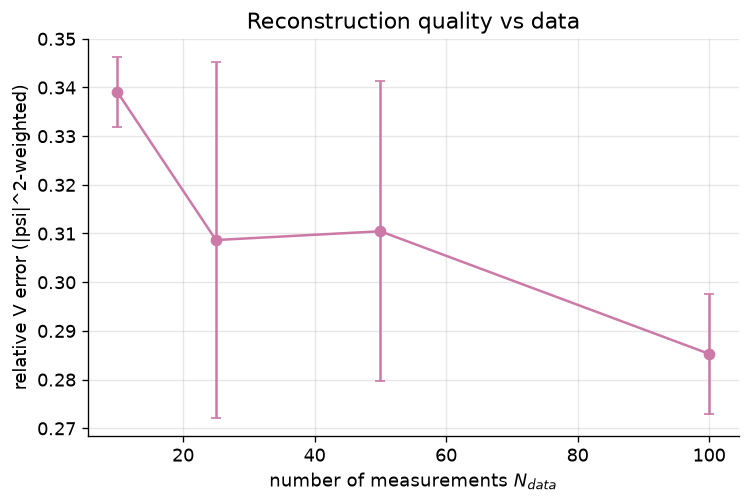

In [2]:
inv = pd.read_csv('../results/inverse/inverse.csv'); display(inv)
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.errorbar(inv['n_data'], inv['V_rel_error_mean'], yerr=inv['V_rel_error_std'],
            fmt='o-', color=CB['purple'], capsize=3)
ax.set_xlabel('number of measurements $N_{data}$')
ax.set_ylabel('relative V error (|psi|^2-weighted)')
ax.set_title('Reconstruction quality vs data'); plt.show()

## Live demo: reconstruct V from a handful of points

In [3]:
from src import potentials as P
from src.fdm import solve_fdm
from experiments.inverse_problem import train_inverse, eval_inverse
lam = 0.3; domain = (-6, 6)
fdm = solve_fdm(P.anharmonic_oscillator(lam=lam, domain=domain), n_per_dim=1000, k=1)
axis = fdm.axis; psi_true = fdm.wavefunctions[0]; psi_true *= np.sign(psi_true[500]+1e-9)
V_true = 0.5*axis**2 + lam*axis**4
rng = np.random.default_rng(0); probs = psi_true**2/psi_true.dot(psi_true)
idx = rng.choice(len(axis), size=15, replace=False, p=probs)
model, _ = train_inverse(axis[idx], psi_true[idx], domain, 500, 64, 4, 2500,
                         3e-3, 100., 1., 1., 1., 1e-3, seed=0)
psi_p, V_p = eval_inverse(model, axis)

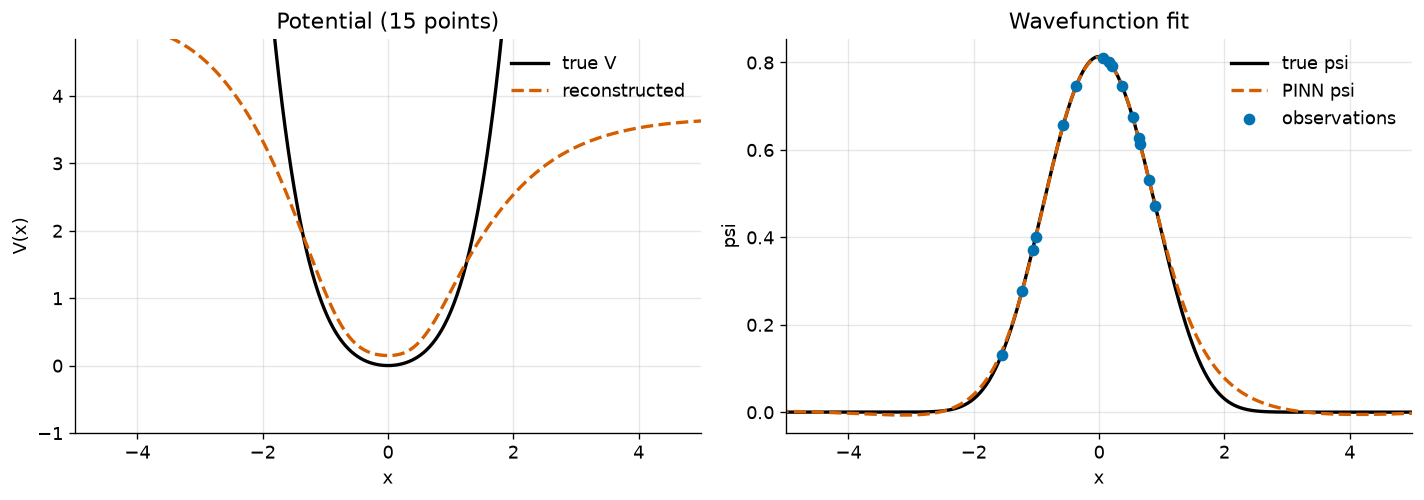

In [4]:
supp = psi_true**2 > 1e-2*(psi_true**2).max()
shift = np.trapezoid((V_true[supp]-V_p[supp]), axis[supp])/(axis[supp][-1]-axis[supp][0])
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].plot(axis, V_true, color=CB['black'], lw=2, label='true V')
ax[0].plot(axis, V_p+shift, '--', color=CB['red'], lw=2, label='reconstructed')
ax[0].set_xlim(-5, 5); ax[0].set_ylim(-1, V_true[supp].max()*1.2)
ax[0].set_xlabel('x'); ax[0].set_ylabel('V(x)'); ax[0].legend(); ax[0].set_title('Potential (15 points)')
ax[1].plot(axis, psi_true, color=CB['black'], lw=2, label='true psi')
ax[1].plot(axis, psi_p*np.sign(psi_p[500]), '--', color=CB['red'], lw=2, label='PINN psi')
ax[1].scatter(axis[idx], psi_true[idx], color=CB['blue'], zorder=3, label='observations')
ax[1].set_xlim(-5, 5); ax[1].set_xlabel('x'); ax[1].set_ylabel('psi'); ax[1].legend()
ax[1].set_title('Wavefunction fit'); fig.tight_layout(); plt.show()

**Takeaway.** With the Schrodinger equation as a constraint, even ~10-25 scattered measurements recover the potential's shape -- something plain interpolation of so few points cannot do. Quality saturates with more data because the bottleneck is the joint psi/V optimization, not the number of measurements.